In [13]:
from lossy_boson import solve_dynamics_vacuum, get_initial_state
from direct_integration_lossy_boson import run_twa_bundle
import matplotlib.pyplot as plt
import jax.numpy as jnp
import jax

In [24]:
# 1. Physical Parameters (Mapped from QuTiP)
omega_0 = 1.0  # wa in QuTiP
kappa = 0.01    # Loss rate
g = 0.05       # Coupling strength
kBT = 0        # Near-zero temperature (vacuum limit)
B_field = jnp.array([0.0, 0.0, 1.0])

# 2. Simulation Grid
t_max = 100 
num_steps = 5000
t_grid = jnp.linspace(0, t_max, num_steps)

N = 30

v_init = [1, 0, 0]
rho0 = get_initial_state(v_init, N)

# Qutip
res = solve_dynamics_vacuum(Bx=B_field[0], By=B_field[1], Bz=B_field[2], wa=omega_0, g=g, kappa=kappa, times=t_grid, rho0=rho0, N = N)

# TWA
n_trajectories = 10_000 # DTWA needs large N for convergence
master_key = jax.random.PRNGKey(42)
keys = jax.random.split(master_key, n_trajectories)

twa_results = run_twa_bundle(
    keys=keys, 
    t_grid=t_grid, 
    omega_0=omega_0, 
    kappa=kappa, 
    B_field=B_field, 
    g=g, 
    initial_direction=jnp.array(v_init),
    coupling_type = 'full',
    batch_size=5000
)

/home/juardilag/miniconda3/envs/work/lib/python3.14/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


3. Starting DTWA: 10000 trajectories in 2 batches.


DTWA Batches:   0%|          | 0/2 [00:00<?, ?it/s]

# Results

In [25]:
t_list = res.times
expect_x = res.expect[0]
expect_y = res.expect[1]
expect_z = res.expect[2]
boson_num = res.expect[3]

expect_x_twa = twa_results[:, 0]
expect_y_twa = twa_results[:, 1]
expect_z_twa = twa_results[:, 2]

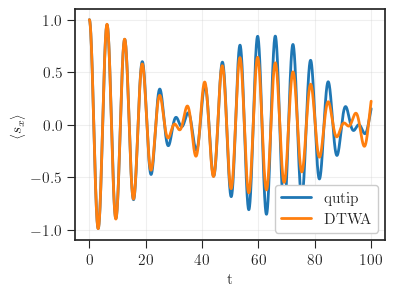

In [26]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])
fig, ax = plt.subplots(1, figsize=(4, 3))
plt.plot(t_list, expect_x, label = 'qutip', linewidth = 2)
plt.plot(t_grid, expect_x_twa, label = 'DTWA', linewidth = 2)
plt.xlabel('t')
plt.ylabel(r'$\langle s_x \rangle$')
plt.legend()
plt.ylim(-1.1, 1.1)
plt.grid(alpha = 0.3)
plt.show()

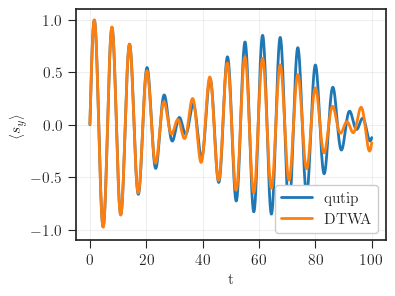

In [27]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])
fig, ax = plt.subplots(1, figsize=(4, 3))
plt.plot(t_list, expect_y, label = 'qutip', linewidth = 2)
plt.plot(t_grid, expect_y_twa, label = 'DTWA', linewidth = 2)
plt.xlabel('t')
plt.ylabel(r'$\langle s_y \rangle$')
plt.ylim(-1.1, 1.1)
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

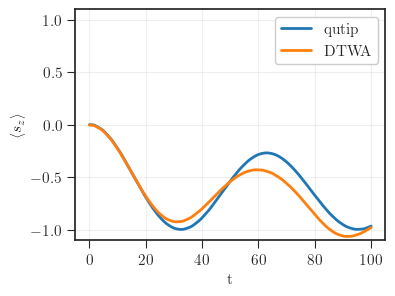

In [28]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])
fig, ax = plt.subplots(1, figsize=(4, 3))
plt.plot(t_list, expect_z, label = 'qutip', linewidth = 2)
plt.plot(t_list, expect_z_twa, label = 'DTWA', linewidth = 2)
plt.xlabel('t')
plt.ylim(-1.1, 1.1)
plt.ylabel(r'$\langle s_z \rangle$')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()